# Experiment 1: Skill Frequency in Data Science Job Postings

Core skills such as Python, SQL, and statistics will have the highest frequency across job postings, indicating baseline requirements for data science roles -- does it supports by the real world data? 

This notebook tests the hypothesis that core skills such as Python, SQL, and statistics appear most frequently across data science job postings.


In [1]:
from IPython.display import display

from pathlib import Path
import matplotlib.pyplot as plt
import pandas as pd

from helpers import parse_salary, extract_skill_frequencies, SKILL_PATTERNS
from job_dataset_union import build_unified_jobs_df

In [2]:
data_paths = [
    # Dataset 1 
    Path("data/glassdoor_jobs_2023.csv"),
    # Dataset 2
    Path("data/data_science_job_posts_2025.csv"),
]

df = build_unified_jobs_df()

required_column = "job_description_skills"
if required_column not in df.columns:
    raise ValueError(f"Expected '{required_column}' column in the unified dataset.")

job_descriptions = df[required_column].fillna("").astype(str)

glassdoor_2023_mask = df['source_dataset'] == 'glassdoor_2023'
df_for_hype_check = df.loc[glassdoor_2023_mask].copy()
job_descriptions_for_hype_check = df_for_hype_check[required_column].fillna("").astype(str)

print(f"Loaded {len(df)} job postings from {', '.join(str(path) for path in data_paths)}.")
print(df['source_dataset'].value_counts())


Loaded 2444 job postings from data\glassdoor_jobs_2023.csv, data\data_science_job_posts_2025.csv.
source_dataset
glassdoor_2023                 1500
data_science_job_posts_2025     944
Name: count, dtype: int64


In [3]:
df.head()

,job_title,location,sector,salary_range,industry,job_description_skills,source_dataset,Rating,Company Name,Size,...,Type of ownership,Revenue,seniority_level,status,company,post_date,headquarter,ownership,company_size,revenue
0,Data Scientist,Remote,Education,-1,Primary & Secondary Schools,Job Overview\nA Data Scientist at ExploreLearn...,glassdoor_2023,4.2,Cambium Learning Group\n4.3,1001 to 5000 Employees,...,Company - Private,$500 million to $1 billion (USD),NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2024 University Graduate - Data Scientist,"San Jose, CA",Information Technology,Employer Provided Salary:$83K - $153K,Computer Hardware Development,Our Company\n\nChanging the world through digi...,glassdoor_2023,4.4,Adobe\n4.4,10000+ Employees,...,Company - Public,$5 to $10 billion (USD),NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Data Scientist – Entry Level 2024,"Atlanta, GA",Information Technology,Employer Provided Salary:$71K - $133K,Information Technology Support Services,Introduction\nRanked by Forbes as one of the w...,glassdoor_2023,3.9,IBM\n3.9,10000+ Employees,...,Company - Public,$10+ billion (USD),NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Data Scientist 2,"Redmond, WA",Information Technology,Employer Provided Salary:$94K - $183K,Computer Hardware Development,The Microsoft 365 team is looking for a Data S...,glassdoor_2023,4.3,Microsoft\n4.3,10000+ Employees,...,Company - Public,$10+ billion (USD),NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,Entry Level Data Scientist 2023/2024,"The Woodlands, TX",Manufacturing,$48K - $78K (Glassdoor est.),Chemical Manufacturing,"You may not realize it, but you’ve likely used...",glassdoor_2023,3.9,CPChem\n3.9,1001 to 5000 Employees,...,Company - Private,$10+ billion (USD),NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [4]:
df.tail()

,job_title,location,sector,salary_range,industry,job_description_skills,source_dataset,Rating,Company Name,Size,...,Type of ownership,Revenue,seniority_level,status,company,post_date,headquarter,ownership,company_size,revenue
2439,data scientist,"Bengaluru, Karnataka, India",<NA>,"€33,288 - €53,080",Technology,"['pytorch', 'python', 'sql', 'machine learning...",data_science_job_posts_2025,NaN,NaN,NaN,...,NaN,NaN,senior,NaN,company_171,a day ago,"Armonk, NY, US",Public,"524,598",€120.29B
2440,machine learning engineer,"Melbourne, Victoria, Australia",<NA>,"€64,290",Retail,"['amazon', 'machine learning']",data_science_job_posts_2025,NaN,NaN,NaN,...,NaN,NaN,senior,NaN,company_134,a month ago,"Seattle, WA, US",Public,"865,456",€838.78B
2441,data scientist,"McLean, VA",<NA>,"€145,904 - €166,510",Retail,"['spark', 'aws', 'r', 'python', 'scala', 'sql'...",data_science_job_posts_2025,NaN,NaN,NaN,...,NaN,NaN,midlevel,on-site,company_395,11 days ago,"McLean, VA, US",Public,"55,150",€36.29B
2442,data scientist,"New York, NY",<NA>,"€159,149 - €181,595",Retail,"['spark', 'aws', 'r', 'python', 'scala', 'sql'...",data_science_job_posts_2025,NaN,NaN,NaN,...,NaN,NaN,midlevel,on-site,company_395,17 days ago,"McLean, VA, US",Public,"55,110",€36.34B
2443,data scientist,"San Diego, CA",<NA>,"€195,486 - €201,926",Technology,"['r', 'python', 'scala', 'sql', 'machine learn...",data_science_job_posts_2025,NaN,NaN,NaN,...,NaN,NaN,senior,on-site,company_844,8 days ago,"Mountain View, CA, US",Public,"17,040",€95.22B


In [5]:
skill_frequency = extract_skill_frequencies(job_descriptions, SKILL_PATTERNS)

skill_frequency

,Skill,Mention Count,Percentage of Postings
0,Machine Learning,984,40.26
1,Python,796,32.57
2,SQL,533,21.81
3,R,449,18.37
4,Statistics,320,13.09
...,...,...,...
59,Kafka,1,0.04
60,MySQL,1,0.04
61,CatBoost,0,0.00
62,MongoDB,0,0.00


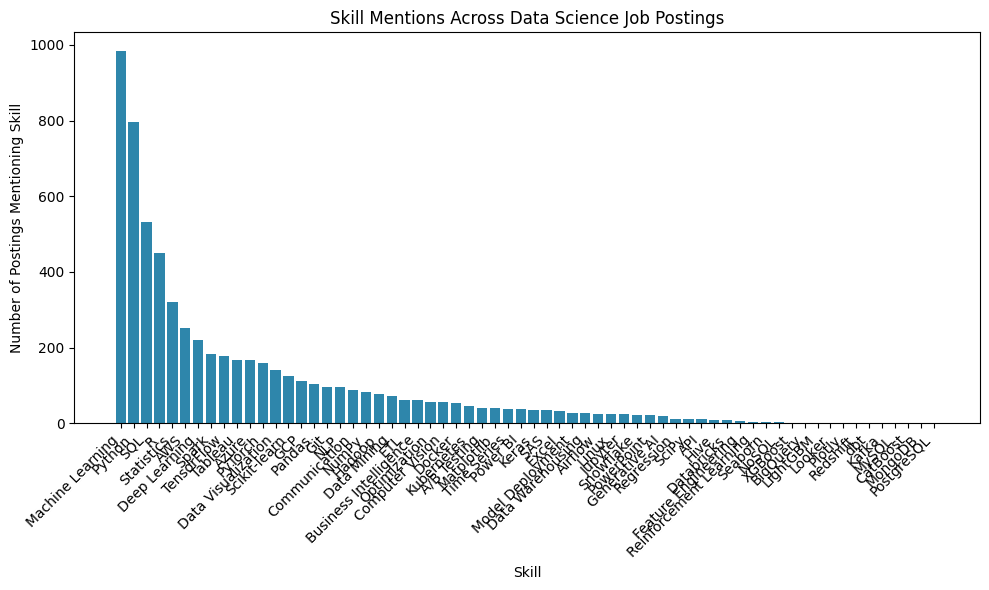

In [6]:
plt.figure(figsize=(10, 6))
plt.bar(skill_frequency["Skill"], skill_frequency["Mention Count"], color="#2E86AB")
plt.title("Skill Mentions Across Data Science Job Postings")
plt.xlabel("Skill")
plt.ylabel("Number of Postings Mentioning Skill")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

In [7]:
core_skills = skill_frequency[skill_frequency["Skill"].isin(["Machine Learning", 
                                                             "Deep Learning",
                                                             "NLP",
                                                             "AWS",
                                                             "Python",
                                                             "SQL",
                                                             "Statistics"])]

core_skills

,Skill,Mention Count,Percentage of Postings
0,Machine Learning,984,40.26
1,Python,796,32.57
2,SQL,533,21.81
4,Statistics,320,13.09
5,AWS,253,10.35
6,Deep Learning,220,9.00
17,NLP,95,3.89


## Interpretation


The hypothesis is **partially supported** by this dataset. While Python and statistics appear as baseline skills, Machine Learning dominates as the most frequently mentioned skill, followed by Python, SQL, and statistics.

Based on the actual data from 2,445 job postings, the ranking of core skills is:
* Machine Learning: 984 postings (40.26%)
* Python: 796 postings (32.57%)
* SQL: 533 postings (21.81%)
* Statistics: 320 postings (13.09%)
* AWS: 253 postings (10.35%)
* Deep Learning: 220 postings (9.00%)
* NLP: 95 postings (3.89%)

This suggests that Machine Learning has become a fundamental requirement in data science roles, surpassing traditional programming and statistical skills in frequency. Python remains a strong baseline, while SQL and statistics are important but less dominant than expected. Cloud platforms like AWS also show significant presence, indicating the growing importance of cloud infrastructure in data science."


# Cloud Skills vs. `R`

This section checks whether cloud skills have become more prominent than `R`, the second traditional analytics language. We evaluate this in two ways:

- the **sum of mentions** across `AWS`, `Azure`, and `GCP`
- the number of **unique postings** mentioning at least one of these cloud skills

This distinction matters because one job posting can mention more than one cloud platform.

In [8]:
# Concrete ML-related signals used to distinguish specific ML requirements from broad ML mentions.
ml_related_skills = [
    "Deep Learning",
    "NLP",
    "Computer Vision",
    "Generative AI",
    "Reinforcement Learning",
    "Scikit-learn",
    "TensorFlow",
    "PyTorch",
    "Keras",
    "XGBoost",
    "LightGBM",
    "CatBoost",
]

ml_mask = job_descriptions_for_hype_check.str.contains(SKILL_PATTERNS["Machine Learning"], case=False, regex=True)

ml_related_flags = pd.DataFrame({
    skill: job_descriptions_for_hype_check.str.contains(SKILL_PATTERNS[skill], case=False, regex=True)
    for skill in ml_related_skills
})

ml_with_related_mask = ml_mask & ml_related_flags.any(axis=1)
ml_without_related_mask = ml_mask & ~ml_related_flags.any(axis=1)

ml_hype_summary = pd.DataFrame({
    "Category": [
        "ML mention without concrete ML skill",
        "ML mention with at least one concrete ML skill",
    ],
    "Postings": [
        int(ml_without_related_mask.sum()),
        int(ml_with_related_mask.sum()),
    ],
})
ml_hype_summary["Share of ML Postings (%)"] = (
    ml_hype_summary["Postings"] / int(ml_mask.sum()) * 100
).round(2)

related_skill_counts_in_ml = pd.DataFrame({
    "Skill": ml_related_skills,
    "Postings": [int((ml_mask & ml_related_flags[skill]).sum()) for skill in ml_related_skills],
}).sort_values("Postings", ascending=False).reset_index(drop=True)

print(f"Machine Learning appears in {int(ml_mask.sum())} job postings.")
display(ml_hype_summary)
display(related_skill_counts_in_ml.head(8))

Machine Learning appears in 404 job postings.


,Category,Postings,Share of ML Postings (%)
0,ML mention without concrete ML skill,301,74.5
1,ML mention with at least one concrete ML skill,103,25.5


,Skill,Postings
0,NLP,65
1,Computer Vision,50
2,Deep Learning,28
3,Scikit-learn,13
4,TensorFlow,12
5,Generative AI,10
6,PyTorch,10
7,Reinforcement Learning,3


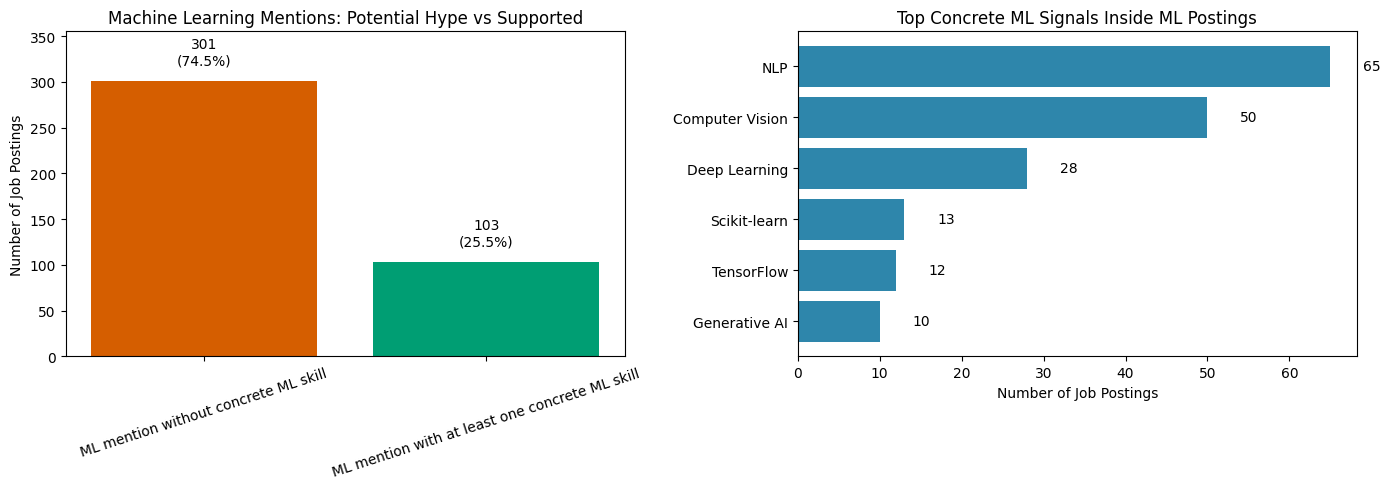

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Comparison of broad ML mentions versus more concrete ML requirements.
summary_colors = ["#D55E00", "#009E73"]
axes[0].bar(ml_hype_summary["Category"], ml_hype_summary["Postings"], color=summary_colors)
axes[0].set_title('Machine Learning Mentions: Potential Hype vs Supported')
axes[0].set_ylabel('Number of Job Postings')
axes[0].tick_params(axis='x', rotation=18)

for idx, row in ml_hype_summary.iterrows():
    axes[0].text(
        idx,
        row["Postings"] + 15,
        f"{row['Postings']}\n({row['Share of ML Postings (%)']}%)",
        ha='center',
        va='bottom'
    )

axes[0].set_ylim(0, ml_hype_summary["Postings"].max() * 1.18)

# Most common concrete ML signals found inside postings that mention Machine Learning.
top_related = related_skill_counts_in_ml.head(6).iloc[::-1]
axes[1].barh(top_related["Skill"], top_related["Postings"], color="#2E86AB")
axes[1].set_title('Top Concrete ML Signals Inside ML Postings')
axes[1].set_xlabel('Number of Job Postings')

for idx, value in enumerate(top_related["Postings"]):
    axes[1].text(value + 4, idx, str(value), va='center')

plt.tight_layout()
plt.show()

## Conclusion

Within the **Glassdoor 2023** subset, **301** out of **404** job postings that mention **Machine Learning** (**74.50%**) do **not** mention any additional concrete ML-related skill from our selected list. Only **103** postings (**25.50%**) pair `Machine Learning` with at least one more specific ML signal.

This suggests that `Machine Learning` is often used as a broad or high-level term in Glassdoor job ads, rather than always indicating explicit hands-on ML tooling requirements. The most common supporting signals were **NLP (65)**, **Computer Vision (50)**, and **Deep Learning (28)**.

At the same time, this is an approximate estimate of "hype," because it depends on the selected skill list and on regex-based keyword matching.

,Skill,Mention Count,Percentage of Postings
0,AWS,253,10.35
1,Azure,166,6.79
2,GCP,112,4.58
3,R,449,18.37


,Measure,Count,Percentage of Postings
0,Sum of AWS + Azure + GCP mentions,531,NaN
1,Postings with any cloud skill,312,12.77
2,Postings with R,449,18.37


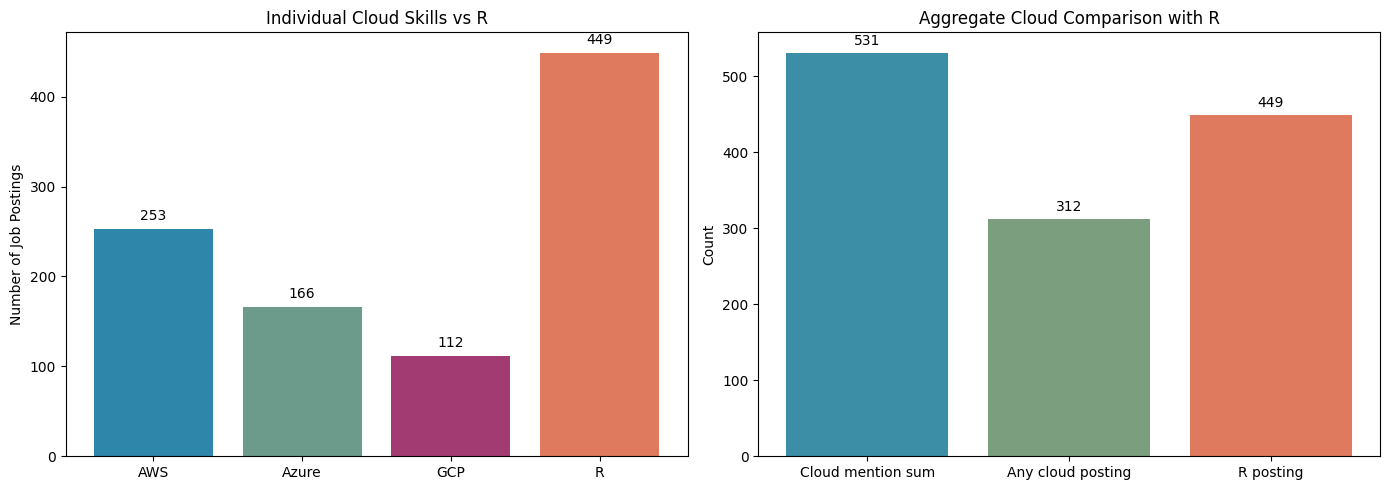

In [10]:
cloud_skills = ["AWS", "Azure", "GCP"]

cloud_skill_rows = []
cloud_skill_flags = {}
for skill in cloud_skills + ["R"]:
    mask = job_descriptions.str.contains(SKILL_PATTERNS[skill], case=False, regex=True)
    cloud_skill_flags[skill] = mask
    cloud_skill_rows.append({
        "Skill": skill,
        "Mention Count": int(mask.sum()),
        "Percentage of Postings": round(mask.sum() / len(df) * 100, 2),
    })

cloud_skill_summary = pd.DataFrame(cloud_skill_rows)
any_cloud_mask = pd.DataFrame({skill: cloud_skill_flags[skill] for skill in cloud_skills}).any(axis=1)

cloud_vs_r_summary = pd.DataFrame({
    "Measure": [
        "Sum of AWS + Azure + GCP mentions",
        "Postings with any cloud skill",
        "Postings with R",
    ],
    "Count": [
        int(cloud_skill_summary[cloud_skill_summary["Skill"].isin(cloud_skills)]["Mention Count"].sum()),
        int(any_cloud_mask.sum()),
        int(cloud_skill_flags["R"].sum()),
    ],
})
cloud_vs_r_summary["Percentage of Postings"] = [
    None,
    round(any_cloud_mask.sum() / len(df) * 100, 2),
    round(cloud_skill_flags["R"].sum() / len(df) * 100, 2),
]

display(cloud_skill_summary)
display(cloud_vs_r_summary)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

skill_plot = cloud_skill_summary.set_index("Skill").loc[["AWS", "Azure", "GCP", "R"]].reset_index()
axes[0].bar(skill_plot["Skill"], skill_plot["Mention Count"], color=["#2E86AB", "#6C9A8B", "#A23B72", "#E07A5F"])
axes[0].set_title('Individual Cloud Skills vs R')
axes[0].set_ylabel('Number of Job Postings')

for idx, row in skill_plot.iterrows():
    axes[0].text(idx, row["Mention Count"] + 10, str(row["Mention Count"]), ha='center')

comparison_labels = ["Cloud mention sum", "Any cloud posting", "R posting"]
comparison_counts = cloud_vs_r_summary["Count"].tolist()
axes[1].bar(comparison_labels, comparison_counts, color=["#3B8EA5", "#7A9E7E", "#E07A5F"])
axes[1].set_title('Aggregate Cloud Comparison with R')
axes[1].set_ylabel('Count')

for idx, value in enumerate(comparison_counts):
    axes[1].text(idx, value + 10, str(value), ha='center')

plt.tight_layout()
plt.show()

## Conclusion

This hypothesis is **partially supported**. The summed mention count for `AWS`, `Azure`, and `GCP` is **531**, which is higher than the `R` mention count of **449**.

However, when we switch from summed mentions to unique postings, only **312** postings (**12.77%**) mention at least one of these cloud skills, while **449** postings (**18.37%**) mention `R`.

So cloud platforms collectively generate more total mentions than `R`, but they do not yet appear in more unique job postings than `R` in this dataset.

# Production-Oriented Skills in High- vs Low-Salary Roles

This section checks whether cloud and deployment-oriented skills are more common in higher-paying jobs. To create a clear comparison, we:

- convert salary ranges to approximate annual USD using `parse_salary`
- keep only postings with a parsed salary
- compare the **bottom salary quartile** with the **top salary quartile**

The production-oriented skill set includes `AWS`, `Docker`, `Kubernetes`, and `Model Deployment` (which also captures MLOps-related phrasing).

,Group,Salary Threshold,Postings
0,Low salary quartile,"<= $102,000",518
1,High salary quartile,">= $165,000",519


,Skill,Low Salary %,High Salary %
0,AWS,14.67,13.29
1,Docker,6.18,1.73
2,Kubernetes,3.67,1.93
3,Model Deployment,0.00,0.58
4,Any production-oriented skill,16.22,14.64


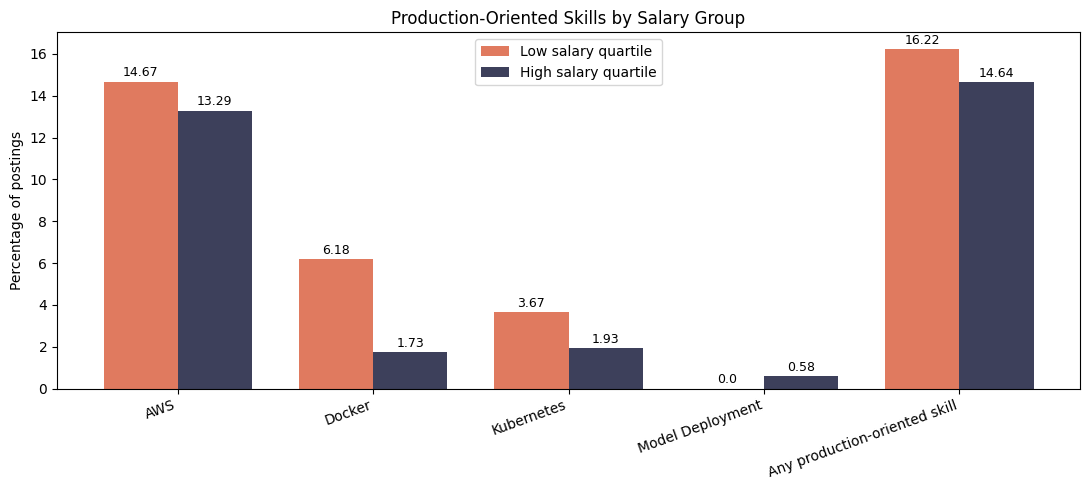

In [11]:
salary_analysis_df = df.copy()
salary_analysis_df["salary_usd"] = salary_analysis_df["salary_range"].apply(parse_salary)
salary_analysis_df = salary_analysis_df[salary_analysis_df["salary_usd"].notna()].copy()

low_salary_cutoff = salary_analysis_df["salary_usd"].quantile(0.25)
high_salary_cutoff = salary_analysis_df["salary_usd"].quantile(0.75)

low_salary_mask = salary_analysis_df["salary_usd"] <= low_salary_cutoff
high_salary_mask = salary_analysis_df["salary_usd"] >= high_salary_cutoff

production_skills = ["AWS", "Docker", "Kubernetes", "Model Deployment"]
production_flags = pd.DataFrame({
    skill: salary_analysis_df["job_description_skills"].fillna("").astype(str).str.contains(SKILL_PATTERNS[skill], case=False, regex=True)
    for skill in production_skills
})
any_production_mask = production_flags.any(axis=1)

salary_group_summary = pd.DataFrame({
    "Group": ["Low salary quartile", "High salary quartile"],
    "Salary Threshold": [f"<= ${low_salary_cutoff:,.0f}", f">= ${high_salary_cutoff:,.0f}"],
    "Postings": [int(low_salary_mask.sum()), int(high_salary_mask.sum())],
})

production_skill_rows = []
for skill in production_skills:
    production_skill_rows.append({
        "Skill": skill,
        "Low Salary %": round((low_salary_mask & production_flags[skill]).sum() / low_salary_mask.sum() * 100, 2),
        "High Salary %": round((high_salary_mask & production_flags[skill]).sum() / high_salary_mask.sum() * 100, 2),
    })

production_skill_rows.append({
    "Skill": "Any production-oriented skill",
    "Low Salary %": round((low_salary_mask & any_production_mask).sum() / low_salary_mask.sum() * 100, 2),
    "High Salary %": round((high_salary_mask & any_production_mask).sum() / high_salary_mask.sum() * 100, 2),
})

production_skill_summary = pd.DataFrame(production_skill_rows)

display(salary_group_summary)
display(production_skill_summary)

plot_df = production_skill_summary.melt(id_vars="Skill", var_name="Salary Group", value_name="Percentage")
plot_df["Salary Group"] = plot_df["Salary Group"].replace({"Low Salary %": "Low salary quartile", "High Salary %": "High salary quartile"})

fig, ax = plt.subplots(figsize=(11, 5))
bar_width = 0.38
positions = range(len(production_skill_summary))

ax.bar([p - bar_width / 2 for p in positions], production_skill_summary["Low Salary %"], width=bar_width, label='Low salary quartile', color="#E07A5F")
ax.bar([p + bar_width / 2 for p in positions], production_skill_summary["High Salary %"], width=bar_width, label='High salary quartile', color="#3D405B")

ax.set_xticks(list(positions))
ax.set_xticklabels(production_skill_summary["Skill"], rotation=20, ha='right')
ax.set_ylabel('Percentage of postings')
ax.set_title('Production-Oriented Skills by Salary Group')
ax.legend()

for p, value in enumerate(production_skill_summary["Low Salary %"]):
    ax.text(p - bar_width / 2, value + 0.25, str(value), ha='center', fontsize=9)

for p, value in enumerate(production_skill_summary["High Salary %"]):
    ax.text(p + bar_width / 2, value + 0.25, str(value), ha='center', fontsize=9)

plt.tight_layout()
plt.show()

## Conclusion

This hypothesis is **not supported** by the current dataset. In the bottom salary quartile (<= **$102,000**, **518** postings), `AWS`, `Docker`, and `Kubernetes` all appear more often than in the top salary quartile (>= **$165,000**, **519** postings).

For the combined measure, at least one production-oriented skill appears in **16.22%** of low-salary postings versus **14.64%** of high-salary postings. `Model Deployment` is slightly more common in the high-salary group (**0.58%** vs **0.00%**), but it remains rare overall.

This suggests that higher salary does not automatically correspond to more explicit production-oriented tooling requirements in this dataset.

## Machine Learning "Hype" Check

This section estimates how often job postings mention **Machine Learning** without mentioning any more concrete ML-related subfield or library.

Because this check requires full job-description text, it uses only the **Glassdoor 2023** subset rather than the full merged dataset.

For this check, a posting is treated as a potential **"hype" mention** if it includes `Machine Learning` but does **not** include any of the following signals: `Deep Learning`, `NLP`, `Computer Vision`, `Generative AI`, `Reinforcement Learning`, `Scikit-learn`, `TensorFlow`, `PyTorch`, `Keras`, `XGBoost`, `LightGBM`, or `CatBoost`.

In [12]:
# Reuse the Glassdoor 2023 subset prepared in the loading cell.
# Keeping this check here makes the later hype-analysis section self-explanatory when read in order.

len(job_descriptions_for_hype_check)

1500

In [13]:
df_for_hype_check.head()

,job_title,location,sector,salary_range,industry,job_description_skills,source_dataset,Rating,Company Name,Size,...,Type of ownership,Revenue,seniority_level,status,company,post_date,headquarter,ownership,company_size,revenue
0,Data Scientist,Remote,Education,-1,Primary & Secondary Schools,Job Overview\nA Data Scientist at ExploreLearn...,glassdoor_2023,4.2,Cambium Learning Group\n4.3,1001 to 5000 Employees,...,Company - Private,$500 million to $1 billion (USD),NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2024 University Graduate - Data Scientist,"San Jose, CA",Information Technology,Employer Provided Salary:$83K - $153K,Computer Hardware Development,Our Company\n\nChanging the world through digi...,glassdoor_2023,4.4,Adobe\n4.4,10000+ Employees,...,Company - Public,$5 to $10 billion (USD),NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Data Scientist – Entry Level 2024,"Atlanta, GA",Information Technology,Employer Provided Salary:$71K - $133K,Information Technology Support Services,Introduction\nRanked by Forbes as one of the w...,glassdoor_2023,3.9,IBM\n3.9,10000+ Employees,...,Company - Public,$10+ billion (USD),NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Data Scientist 2,"Redmond, WA",Information Technology,Employer Provided Salary:$94K - $183K,Computer Hardware Development,The Microsoft 365 team is looking for a Data S...,glassdoor_2023,4.3,Microsoft\n4.3,10000+ Employees,...,Company - Public,$10+ billion (USD),NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,Entry Level Data Scientist 2023/2024,"The Woodlands, TX",Manufacturing,$48K - $78K (Glassdoor est.),Chemical Manufacturing,"You may not realize it, but you’ve likely used...",glassdoor_2023,3.9,CPChem\n3.9,1001 to 5000 Employees,...,Company - Private,$10+ billion (USD),NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## Alternative Hype Check: Counting `Machine Learning` + `Deep Learning` as Overhyped

This stricter version treats a posting as **overhyped** if it mentions `Machine Learning` and either:

- mentions only `Machine Learning`, or
- mentions `Machine Learning` together with `Deep Learning`, but no other concrete ML-related skill.

A posting is treated as **supported** only if it mentions `Machine Learning` and also includes at least one more specific ML library or application area beyond `Deep Learning`.

In [14]:
from IPython.display import display

# In this stricter definition, Deep Learning alone does not count as concrete support.
supported_ml_signals = [
    "NLP",
    "Computer Vision",
    "Generative AI",
    "Reinforcement Learning",
    "Scikit-learn",
    "TensorFlow",
    "PyTorch",
    "Keras",
    "XGBoost",
    "LightGBM",
    "CatBoost",
]

ml_mask = job_descriptions_for_hype_check.str.contains(SKILL_PATTERNS["Machine Learning"], case=False, regex=True)
dl_mask = job_descriptions_for_hype_check.str.contains(SKILL_PATTERNS["Deep Learning"], case=False, regex=True)

supported_signal_flags = pd.DataFrame({
    skill: job_descriptions_for_hype_check.str.contains(SKILL_PATTERNS[skill], case=False, regex=True)
    for skill in supported_ml_signals
})
any_supported_signal = supported_signal_flags.any(axis=1)

only_machine_learning_mask = ml_mask & ~dl_mask & ~any_supported_signal
ml_and_dl_only_mask = ml_mask & dl_mask & ~any_supported_signal
ml_supported_mask = ml_mask & any_supported_signal
ml_overhyped_strict_mask = only_machine_learning_mask | ml_and_dl_only_mask

ml_dl_hype_summary = pd.DataFrame({
    "Category": [
        "Only Machine Learning",
        "Machine Learning + Deep Learning only",
        "Machine Learning + concrete ML support",
    ],
    "Postings": [
        int(only_machine_learning_mask.sum()),
        int(ml_and_dl_only_mask.sum()),
        int(ml_supported_mask.sum()),
    ],
})
ml_dl_hype_summary["Share of ML Postings (%)"] = (
    ml_dl_hype_summary["Postings"] / int(ml_mask.sum()) * 100
).round(2)

strict_totals = pd.DataFrame({
    "Group": ["Overhyped under stricter rule", "Supported under stricter rule"],
    "Postings": [int(ml_overhyped_strict_mask.sum()), int(ml_supported_mask.sum())],
})
strict_totals["Share of ML Postings (%)"] = (
    strict_totals["Postings"] / int(ml_mask.sum()) * 100
).round(2)

print(f"Machine Learning appears in {int(ml_mask.sum())} job postings.")
display(ml_dl_hype_summary)
display(strict_totals)

Machine Learning appears in 404 job postings.


,Category,Postings,Share of ML Postings (%)
0,Only Machine Learning,301,74.50
1,Machine Learning + Deep Learning only,15,3.71
2,Machine Learning + concrete ML support,88,21.78


,Group,Postings,Share of ML Postings (%)
0,Overhyped under stricter rule,316,78.22
1,Supported under stricter rule,88,21.78


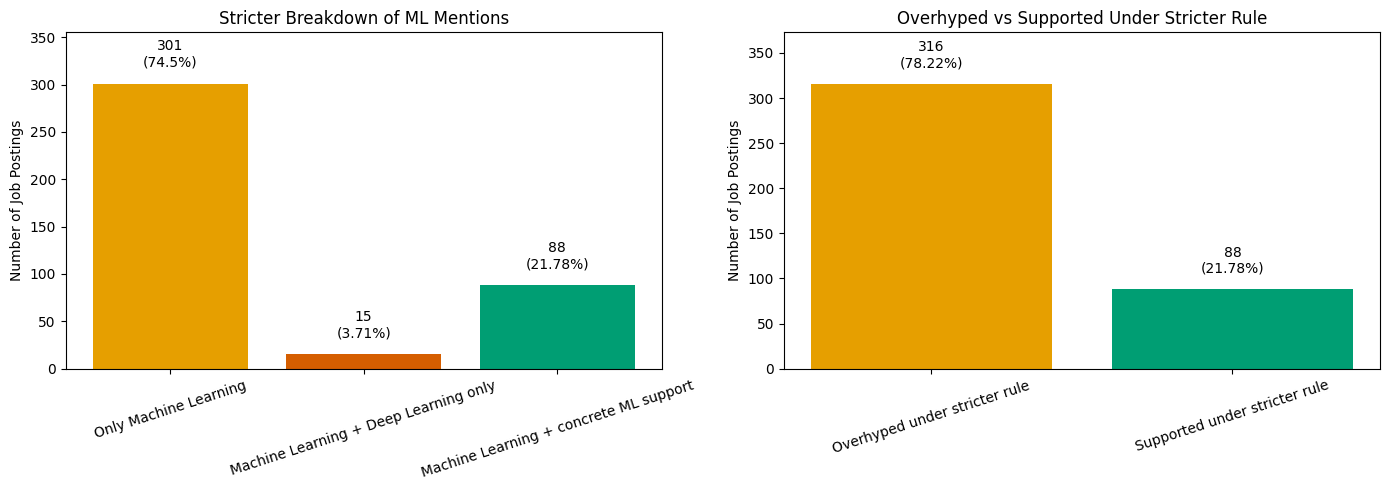

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

detail_colors = ["#E69F00", "#D55E00", "#009E73"]
axes[0].bar(ml_dl_hype_summary["Category"], ml_dl_hype_summary["Postings"], color=detail_colors)
axes[0].set_title('Stricter Breakdown of ML Mentions')
axes[0].set_ylabel('Number of Job Postings')
axes[0].tick_params(axis='x', rotation=18)

for idx, row in ml_dl_hype_summary.iterrows():
    axes[0].text(
        idx,
        row["Postings"] + 15,
        f"{row['Postings']}\n({row['Share of ML Postings (%)']}%)",
        ha='center',
        va='bottom'
    )

axes[0].set_ylim(0, ml_dl_hype_summary["Postings"].max() * 1.18)

total_colors = ["#E69F00", "#009E73"]
axes[1].bar(strict_totals["Group"], strict_totals["Postings"], color=total_colors)
axes[1].set_title('Overhyped vs Supported Under Stricter Rule')
axes[1].set_ylabel('Number of Job Postings')
axes[1].tick_params(axis='x', rotation=18)

for idx, row in strict_totals.iterrows():
    axes[1].text(
        idx,
        row["Postings"] + 15,
        f"{row['Postings']}\n({row['Share of ML Postings (%)']}%)",
        ha='center',
        va='bottom'
    )

axes[1].set_ylim(0, strict_totals["Postings"].max() * 1.18)

plt.tight_layout()
plt.show()

## Conclusion for the Stricter Definition

Within the **Glassdoor 2023** subset, **316** out of **404** `Machine Learning` postings (**78.22%**) fall into the overhyped group under the stricter rule. This includes **301** postings with only `Machine Learning` and **15** postings with `Machine Learning` plus `Deep Learning`, but no other concrete ML signal.

Only **88** postings (**21.78%**) remain in the supported group, meaning they mention `Machine Learning` together with at least one more specific ML library or application area.

This suggests that counting `Deep Learning` alone as support may still overstate how concrete ML requirements are in these Glassdoor job ads.

## Inspecting Overhyped Job Postings

The table below shows the first 40 job postings from the **Glassdoor 2023** subset that satisfy the stricter **overhyped** definition. It is intended for manual reading, so we keep the key metadata and the original text field used for skill matching.

In [16]:
len(df_for_hype_check)

1500

In [17]:
# Build a human-readable table of postings flagged as overhyped under the stricter rule.
company_name = df_for_hype_check["Company Name"].fillna(df_for_hype_check["company"])

overhyped_jobs_to_read = (
    df_for_hype_check.loc[ml_overhyped_strict_mask, ["job_title", "location", "industry", "source_dataset", "job_description_skills"]]
    .assign(company=company_name[ml_overhyped_strict_mask])
    .loc[:, ["job_title", "company", "location", "industry", "source_dataset", "job_description_skills"]]
    .sort_values(["source_dataset", "job_title", "location"], na_position="last")
    .reset_index(drop=True)
    .head(40)
)

print(f"First 40 overhyped postings under the stricter rule: {len(overhyped_jobs_to_read)}")

with pd.option_context("display.max_rows", None, "display.max_colwidth", None):
    display(overhyped_jobs_to_read)

First 40 overhyped postings under the stricter rule: 40


,job_title,company,location,industry,source_dataset,job_description_skills
0,-1,-1,-1,Computer Hardware Development,glassdoor_2023,"Senior Data Scientist Job Description\nLocation: Austin, TX\nAbout Us:\nValkyrie is an applied science firm that builds industry-defining custom AI, ML and Knowledge Engineering solutions. Our team of advanced data scientists support our clients from data normalization all the way through model deployment. Our work can be found across industry from SiriusXM, Activision, Chubb Insurance, and the Department of Defense, to name a few.\nSenior Data Scientist Position:"
1,"AI/ML - Sr Data Scientist, AI/ML Data",Apple\n4.2,"Cupertino, CA",Computer Hardware Development,glassdoor_2023,"Summary\nPosted: Sep 12, 2023\nWeekly Hours: 40\nRole Number:200502488\nDo you get excited by driving product impact via measurement and evaluation, for products and services used by hundreds of millions of people globally? The vision for the AI/ML Data organization is to improve products by using data as the voice of our customers. Within this organization the mission of the Search Analytics team is to inform product evolution through measurement, evaluation, and analysis of the user experience. You will partner with Search engineering teams to improve search quality and guide feature development with data, to deliver amazing search experiences across iPhone, iPad, HomePod, Mac, Watch, tv, across dozens of languages."
2,AVP Data Scientist,Moody's\n3.9,"Charlotte, NC",Research & Development,glassdoor_2023,"Within the Digital Finance team, the Associate Vice President – Data Science (AVP – Data Science) will be responsible for developing machine learning solutions for high-profile data science initiatives. The AVP – Data Science will notably focus on designing and training predictive analytics models and creating high-value-added solutions converting quantitative predictions into actionable insights for the business.\n\nA successful candidate will demonstrate an excellent knowledge of the various steps of a machine learning project, including modeling, data engineering, and MLOps. The candidate should also be innovation-minded, result-oriented, autonomous, and able to deliver finished products, sometimes under short deadlines.\n\nThe data science team will work closely with technology teams, rating and research teams, and other departments. The candidate should therefore be able to collaborate across multiple divisions and communicate clearly and understandably to business representatives unfamiliar with data science.\n\nThe AVP – Data Science will also strive to meet Moody’s values: openness, diversity, inclusivity, respect, and a willingness to learn.\n\nThe duties of the AVP – Data Science include:"
3,Analytics Scientist,Ford Motor Company\n4.0,"Dearborn, MI",Transportation Equipment Manufacturing,glassdoor_2023,"We are the movers of the world and the makers of the future. We get up every day, roll up our sleeves and build a better world - together. At Ford, we’re all a part of something bigger than ourselves. What will you make today?\nThe Ford Motor Credit Company team helps put people behind the wheels of great Ford and Lincoln vehicles. By partnering with dealerships, we provide financing, personalized service and professional expertise to five thousand dealers and more than four million customers in over one hundred countries around the world.\nThe Dealer Analytics team in Credit Analytics is looking for a hardworking and motivated Data Scientist to work on dealer initiatives within Ford Motor Company's Global Data, Insight, and Analytics (GDI&A) organization. In this role, you will be responsible for designing and developing statistical and AI/ML models to solve complex business problems and drive business value to support Ford Motor Credit Company’s Global Dealer & Commercial Risk activities, and report results in appropriate forums."
4,Associate Data Scientist,OneMain Financial\n3.4,"Wilmington, DE",Banking & Le

When analyzing job descriptions, it becomes clear that many roles involve machine learning responsibilities, even when this is not explicitly stated. These requirements are often described using indirect language or without mentioning specific tools or libraries, which makes them difficult to capture using simple frequency-based metrics.

This suggests that a deeper understanding of the context within job descriptions is necessary to determine whether a role is truly related to machine learning or not

Large Language Models (LLMs) can help provide this contextual interpretation. Therefore, we propose analyzing all job descriptions using an LLM to obtain a more accurate and comprehensive view.

# LLM check: 

I started local server within LM Studio with the LLM: qwen/qwen3-4b-thinking-2507 at http://127.0.0.1:1234 

![LLM check screen](pics/llm_check_screen_.png)

In [18]:
from IPython.display import display
import hashlib
import json
import re
import time
from urllib import error, request

LM_STUDIO_BASE_URL = 'http://127.0.0.1:1234/v1'
LM_STUDIO_MODEL = 'qwen/qwen3-4b-thinking-2507'
LM_CACHE_PATH = Path('data/llm_ml_check_glassdoor_2023_cache.csv')
LM_TIMEOUT_SECONDS = 300
LM_TEMPERATURE = 0.0
LM_BATCH_SIZE = 10
LM_JOB_DESCRIPTION_CHAR_LIMIT = 300

# Import the helper functions explicitly because wildcard imports skip underscore-prefixed names.
from helpers_llm import _classify_ml_relevance_batch, _description_hash, _save_llm_cache

In [19]:

LM_ML_PROMPT_TEMPLATE = """/no_think
Classify each vacancy for machine-learning relevance.

Return one result for every source_index.
Use label 1 if machine learning is central to the role.
Use label 0 if machine learning is incidental or hype-like.

Use only the provided description excerpt for each vacancy.

Preferred final answer format is JSON:
{{"results": [{{"source_index": 123, "label": 0, "confidence": 0.75}}]}}

If JSON is not possible, output exactly one compact line per vacancy in this format and nothing else:
source_index=123|label=0|confidence=0.75

Vacancies:
{batch_payload}"""


In [20]:
LM_CACHE_COLUMNS = [
    'source_index',
    'description_hash',
    'llm_ml_label',
    'llm_ml_confidence',
    'model_id',
]



if LM_CACHE_PATH.exists():
    llm_cache_df = pd.read_csv(LM_CACHE_PATH)
else:
    llm_cache_df = pd.DataFrame(columns=LM_CACHE_COLUMNS)

llm_cache_df = llm_cache_df.reindex(columns=LM_CACHE_COLUMNS)
llm_cache_lookup = {}
for record in llm_cache_df.to_dict('records'):
    try:
        cache_key = (
            int(record['source_index']),
            str(record['description_hash']),
            str(record['model_id']),
        )
        cache_value = (int(record['llm_ml_label']), float(record['llm_ml_confidence']))
    except (TypeError, ValueError):
        continue
    llm_cache_lookup[cache_key] = cache_value

lm_regex_ml_mask = job_descriptions_for_hype_check.str.contains(SKILL_PATTERNS['Machine Learning'], case=False, regex=True)
df_for_hype_check['llm_ml_label'] = pd.Series(pd.NA, index=df_for_hype_check.index, dtype='Int64')
df_for_hype_check['llm_ml_confidence'] = pd.Series(pd.NA, index=df_for_hype_check.index, dtype='Float64')

target_indices = list(df_for_hype_check.index[lm_regex_ml_mask])
cached_hits = 0
new_batch_calls = 0
new_rows_labeled = 0
unresolved_rows = []
pending_indices = []

for source_index in target_indices:
    job_description = str(df_for_hype_check.at[source_index, 'job_description_skills'])
    description_hash = _description_hash(job_description)
    cache_key = (int(source_index), description_hash, LM_STUDIO_MODEL)

    if cache_key in llm_cache_lookup:
        label, confidence = llm_cache_lookup[cache_key]
        df_for_hype_check.at[source_index, 'llm_ml_label'] = int(label)
        df_for_hype_check.at[source_index, 'llm_ml_confidence'] = float(confidence)
        cached_hits += 1
    else:
        pending_indices.append(source_index)

for batch_start in range(0, len(pending_indices), LM_BATCH_SIZE):
    batch_indices = pending_indices[batch_start:batch_start + LM_BATCH_SIZE]
    batch_frame = df_for_hype_check.loc[batch_indices, ['job_title', 'job_description_skills']].copy()

    try:
        batch_results = _classify_ml_relevance_batch(batch_frame)
        new_batch_calls += 1
    except RuntimeError as exc:
        unresolved_rows.extend(
            {'source_index': int(source_index), 'error': str(exc)}
            for source_index in batch_indices
        )
        print(f'Batch {batch_start // LM_BATCH_SIZE + 1} failed for {len(batch_indices)} postings.')
        continue

    missing_indices = sorted(set(int(idx) for idx in batch_indices) - set(batch_results))
    for source_index, (label, confidence) in batch_results.items():
        job_description = str(df_for_hype_check.at[source_index, 'job_description_skills'])
        description_hash = _description_hash(job_description)
        cache_key = (int(source_index), description_hash, LM_STUDIO_MODEL)
        llm_cache_lookup[cache_key] = (label, confidence)
        df_for_hype_check.at[source_index, 'llm_ml_label'] = int(label)
        df_for_hype_check.at[source_index, 'llm_ml_confidence'] = float(confidence)
        new_rows_labeled += 1

    if missing_indices:
        unresolved_rows.extend(
            {'source_index': int(source_index), 'error': 'Batch response missing or invalid for this posting.'}
            for source_index in missing_indices
        )

    _save_llm_cache(llm_cache_lookup)
    print(
        f'Processed {min(batch_start + len(batch_indices), len(pending_indices))}/{len(pending_indices)} '
        f'uncached regex-ML postings in batches of up to {LM_BATCH_SIZE}.'
    )

_save_llm_cache(llm_cache_lookup)

print(f'Target regex-ML postings: {len(target_indices)}')
print(f'Cache hits reused: {cached_hits}')
print(f'New LM Studio batch calls: {new_batch_calls}')
print(f'New rows labeled by LM Studio: {new_rows_labeled}')
print(f'Unresolved rows: {len(unresolved_rows)}')

if unresolved_rows:
    display(pd.DataFrame(unresolved_rows).head(10))


Processed 10/19 uncached regex-ML postings in batches of up to 10.
Processed 19/19 uncached regex-ML postings in batches of up to 10.
Target regex-ML postings: 404
Cache hits reused: 385
New LM Studio batch calls: 2
New rows labeled by LM Studio: 19
Unresolved rows: 0


,Category,Count,Share of regex-ML postings (%)
0,Total regex-ML postings,404,100.00
1,LLM says real ML,359,88.86
2,LLM says only mention / not ML,45,11.14
3,Unresolved,0,0.00


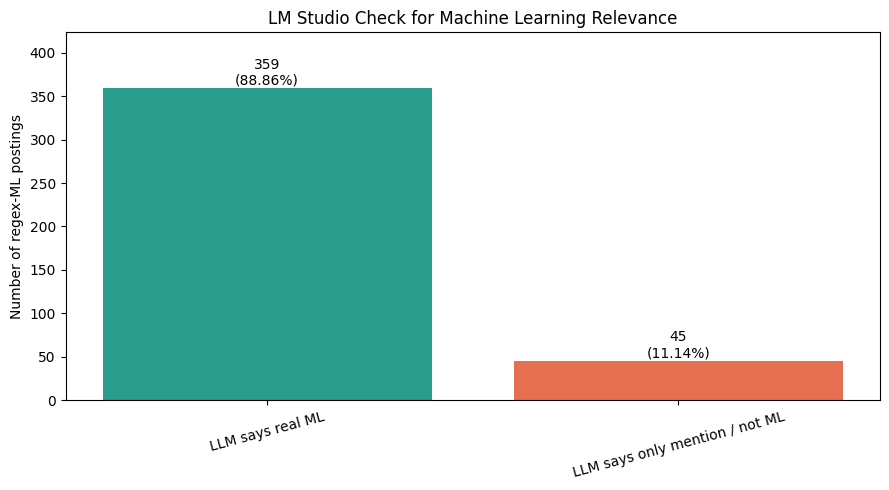

Among 404 regex-ML postings, the LLM classified 359 (88.86%) as genuinely ML-related and 45 (11.14%) as superficial or non-central mentions.

High-confidence examples labeled 0 (not ML):


,job_title,company,location,llm_ml_confidence,job_description_skills
282,Data Engineer,Rockstar Games\n4.3,"Andover, MA",0.95,"At Rockstar Games, we create world-class entertainment experiences.\nA career at Rockstar Games is about being part of a team working on some of the most creatively rewarding and ambitious projects to be found in any entertainment mediu..."
1000,Data Engineer,Q2A Media Services Pvt Ltd,"Smithfield, RI",0.95,"job title- Data Engineering\nMust have citizenship\nMust have's: * Python/Snowflake/AWS *\nPast experience with Informatica or SnapLogic (ETL tools) and exposure to CI/CD pipelines * Oracle PL/SQL skills, writing queries, etc *\nGreat C..."
1120,Data Engineer,Q2A Media Services Pvt Ltd,"Smithfield, RI",0.9,"job title- Data Engineering\nMust have citizenship\nMust have's: * Python/Snowflake/AWS *\nPast experience with Informatica or SnapLogic (ETL tools) and exposure to CI/CD pipelines * Oracle PL/SQL skills, writing queries, etc *\nGreat C..."
910,Data Engineer,Q2A Media Services Pvt Ltd,"Smithfield, RI",0.9,"job title- Data Engineering\nMust have citizenship\nMust have's: * Python/Snowflake/AWS *\nPast experience with Informatica or SnapLogic (ETL tools) and exposure to CI/CD pipelines * Oracle PL/SQL skills, writing queries, etc *\nGreat C..."
1300,Data Engineer,Q2A Media Services Pvt Ltd,"Smithfield, RI",0.9,"job title- Data Engineering\nMust have citizenship\nMust have's: * Python/Snowflake/AWS *\nPast experience with Informatica or SnapLogic (ETL tools) and exposure to CI/CD pipelines * Oracle PL/SQL skills, writing queries, etc *\nGreat C..."


High-confidence examples labeled 1 (true ML):


,job_title,company,location,llm_ml_confidence,job_description_skills
1152,Senior Data Scientist,VidMob\n3.2,Remote,1.0,"Shape the future with intelligence and creativity!\nWe are looking for those passionate about a world where technology and creativity converge, where incredible work is inspired by brilliant analysis. Bold creators, owners and achievers..."
1151,Education Data Scientist,-1,"Pasadena, CA",1.0,"The AI in Education at Expatiate Communications, aims to develop algorithms for the prediction of educational outcomes from attendance records, graduation rates , suspension and k-12 tst data. In order to achieve this goal, novel and cr..."
1163,Data Scientist Machine Learning and Deep Learning,MD Anderson Cancer Center\n4.1,"Houston, TX",1.0,"The primary purpose of this data scientist is to contribute to building the data infrastructure of our flagship platform A3D3a: Adaptive, AI-augmented, Drug Discovery and Development. With expertise in data architecture, the Data Scient..."
1162,Data Scientist,Plymouth Rock Assurance\n3.0,"Boston, MA",1.0,"Overview:\nThe Data Scientists will take a lead role in the end-to-end process of data science initiatives with limited supervision, including but not limited to model design, structure, development and post-deployment model performance..."
703,Cleared Data Scientist (All Levels),Noblis\n4.5,"Chantilly, VA",1.0,"Responsibilities:\nNoblis is seeking to hire a Cleared Data Scientist (All Levels) with an ACTIVE Top Secret with SCI and Polygraph in Chantilly, VA\n\nAs a Data Scientist with our team, you will be working with our federal clients to r..."


In [21]:
company_name_for_lm = df_for_hype_check['Company Name'].fillna(df_for_hype_check['company'])

llm_ml_results_df = (
    df_for_hype_check.loc[
        lm_regex_ml_mask,
        ['job_title', 'location', 'industry', 'source_dataset', 'job_description_skills', 'llm_ml_label', 'llm_ml_confidence'],
    ]
    .assign(company=company_name_for_lm[lm_regex_ml_mask])
    .loc[:, ['job_title', 'company', 'location', 'industry', 'source_dataset', 'llm_ml_label', 'llm_ml_confidence', 'job_description_skills']]
    .copy()
)

total_regex_ml_postings = len(llm_ml_results_df)
real_ml_count = int((llm_ml_results_df['llm_ml_label'] == 1).sum())
non_ml_count = int((llm_ml_results_df['llm_ml_label'] == 0).sum())
unresolved_count = int(llm_ml_results_df['llm_ml_label'].isna().sum())

llm_ml_summary = pd.DataFrame({
    'Category': [
        'Total regex-ML postings',
        'LLM says real ML',
        'LLM says only mention / not ML',
        'Unresolved',
    ],
    'Count': [
        total_regex_ml_postings,
        real_ml_count,
        non_ml_count,
        unresolved_count,
    ],
    'Share of regex-ML postings (%)': [
        100.0,
        round(real_ml_count / total_regex_ml_postings * 100, 2),
        round(non_ml_count / total_regex_ml_postings * 100, 2),
        round(unresolved_count / total_regex_ml_postings * 100, 2),
    ],
})

display(llm_ml_summary)

plot_rows = [
    ('LLM says real ML', real_ml_count, '#2A9D8F'),
    ('LLM says only mention / not ML', non_ml_count, '#E76F51'),
]
if unresolved_count:
    plot_rows.append(('Unresolved', unresolved_count, '#9AA0A6'))

plot_df = pd.DataFrame(plot_rows, columns=['Category', 'Count', 'Color'])
fig, ax = plt.subplots(figsize=(9, 5))
ax.bar(plot_df['Category'], plot_df['Count'], color=plot_df['Color'])
ax.set_title('LM Studio Check for Machine Learning Relevance')
ax.set_ylabel('Number of regex-ML postings')
ax.tick_params(axis='x', rotation=15)

for idx, row in plot_df.iterrows():
    pct = round(row['Count'] / total_regex_ml_postings * 100, 2)
    ax.text(idx, row['Count'] + max(total_regex_ml_postings * 0.01, 1), f"{row['Count']}\n({pct}%)", ha='center')

ax.set_ylim(0, max(plot_df['Count']) * 1.18)
plt.tight_layout()
plt.show()

example_columns = ['job_title', 'company', 'location', 'llm_ml_confidence', 'job_description_skills']
high_confidence_non_ml = llm_ml_results_df[llm_ml_results_df['llm_ml_label'] == 0].sort_values('llm_ml_confidence', ascending=False).head(5)
high_confidence_real_ml = llm_ml_results_df[llm_ml_results_df['llm_ml_label'] == 1].sort_values('llm_ml_confidence', ascending=False).head(5)

print(
    f"Among {total_regex_ml_postings} regex-ML postings, the LLM classified {real_ml_count} "
    f"({real_ml_count / total_regex_ml_postings * 100:.2f}%) as genuinely ML-related and {non_ml_count} "
    f"({non_ml_count / total_regex_ml_postings * 100:.2f}%) as superficial or non-central mentions."
)
if unresolved_count:
    print(f'Unresolved postings: {unresolved_count} ({unresolved_count / total_regex_ml_postings * 100:.2f}%).')

print('\nHigh-confidence examples labeled 0 (not ML):')
with pd.option_context('display.max_colwidth', 240):
    display(high_confidence_non_ml[example_columns])

print('High-confidence examples labeled 1 (true ML):')
with pd.option_context('display.max_colwidth', 240):
    display(high_confidence_real_ml[example_columns])


## Outputs for midterm report

* (1) Variable / Inputs: 404 Glassdoor full-text job descriptions where regex detected Machine Learning.
* (2) Model (max 10 words): Reasoning LLM classification of machine-learning relevance.
* (3) Finding Statement (max 15 words): 44 of 404 descriptions did not confirm genuine machine learning requirements.
* (4) Limitation or Extension of the Model/Findings (max 30 words): Nineteen postings were unresolved; LLM judgments depend on prompt wording, excerpt length, and model interpretation rather than ground-truth labels.